In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import MultiComparison
from scipy import stats

### Loading the data

In [2]:
keep_cols = ["age", "candidate", "ratio_p28"]

df = pd.read_excel("wb-dev-data/raw_data_candidate_dev_analysis.xlsx")
df = df.loc[:, keep_cols]
df.head(20)

,age,candidate,ratio_p28
0,P1,VCAM1,0.786076
1,P7,VCAM1,1.236411
2,P14,VCAM1,1.570349
3,P21,VCAM1,1.198661
4,P28,VCAM1,1.000000
5,P1,HepaCAM,0.084439
6,P7,HepaCAM,0.217927
7,P14,HepaCAM,0.678963
8,P21,HepaCAM,1.021635
9,P28,HepaCAM,1.000000


### Plotting the data

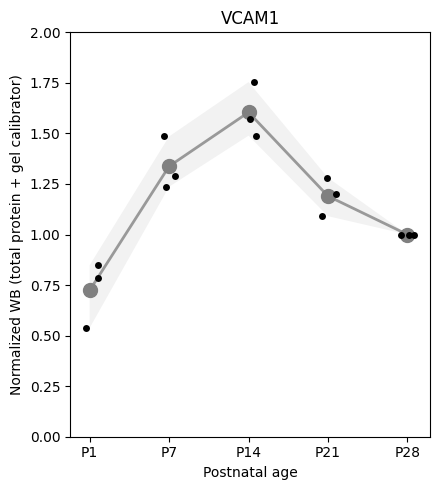

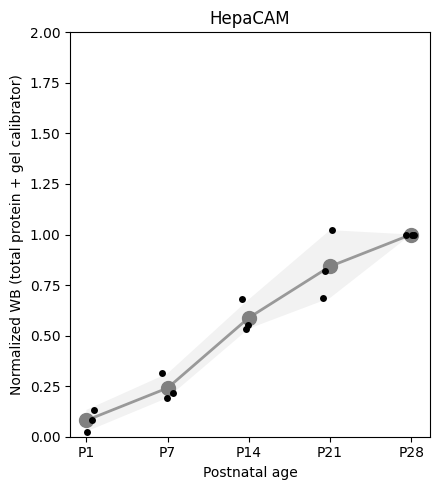

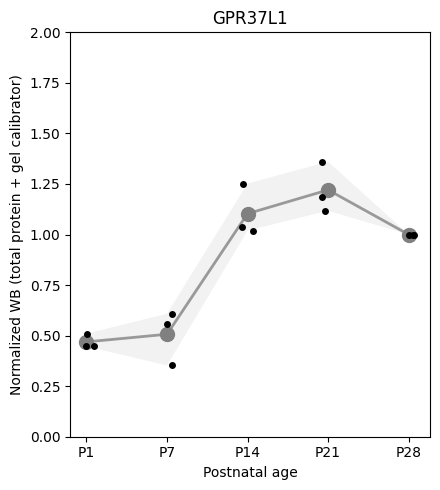

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

age_order = ["P1", "P7", "P14", "P21", "P28"]

for cand in df["candidate"].unique():
    d = df[df["candidate"] == cand].copy()
    d["age"] = pd.Categorical(d["age"], categories=age_order, ordered=True)

    fig, ax = plt.subplots(figsize=(4.5, 5))

    # Grey CI band + grey line (mean)
    sns.lineplot(
        data=d, x="age", y="ratio_p28",
        estimator="mean",
        errorbar=("ci", 95),   
        n_boot=2000,
        color="0.6",          
        linewidth = 2.0,
        ax=ax
    )

    # Make CI band grey explicitly
    for coll in ax.collections:
        coll.set_alpha(0.17)   # light CI
        coll.set_facecolor("0.7")
        coll.set_edgecolor("none")

    # raw points in black
    sns.stripplot(
        data=d, x="age", y="ratio_p28",
        order=age_order,
        jitter=0.1, alpha=1,
        color="black",
        ax=ax,
        zorder = 4
    )

    # mean markers (black)
    means = d.groupby("age", observed=True)["ratio_p28"].mean().reindex(age_order)
    x = np.arange(len(age_order))
    ax.plot(
        x, means.values,
        marker="o", linestyle="None",
        markersize=10,
        markerfacecolor="grey",
        markeredgecolor="grey",
        markeredgewidth=None,
        zorder=3
    )

    ax.set_title(cand)
    ax.set_ylim(0, 2)
    ax.set_xlabel("Postnatal age")
    ax.set_ylabel("Normalized WB (total protein + gel calibrator)")
    plt.tight_layout()

    fig.savefig(
    f"{cand}_development_WB.svg",
    format="svg",
    bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


### Statistical test: one-way ANOVA with Dunnet's test (each vs P28)

In [4]:

results = []
 
for candidate, sub in df.groupby("candidate"):
    print(f"\n{'='*50}")
    print(f"Candidate: {candidate}")
    print(f"{'='*50}")
 
    # One-way ANOVA across all timepoints
    groups = [sub.loc[sub["age"] == age, "ratio_p28"].values
              for age in ["P1", "P7", "P14", "P21", "P28"]]
    f_stat, p_anova = stats.f_oneway(*groups)
    print(f"One-way ANOVA: F = {f_stat:.3f}, p = {p_anova:.4g}")
 
    # Dunnett's test: compare P1, P7, P14, P21 each against P28 (control)
    control = sub.loc[sub["age"] == "P28", "ratio_p28"].values
    treatments = [sub.loc[sub["age"] == age, "ratio_p28"].values
                  for age in ["P1", "P7", "P14", "P21"]]
 
    dunnett_result = stats.dunnett(*treatments, control=control)
 
    for age, stat_val, p_val in zip(["P1", "P7", "P14", "P21"],
                                      dunnett_result.statistic,
                                      dunnett_result.pvalue):
        sig = "*" if p_val < 0.05 else "ns"
        print(f"  {age} vs P28: statistic = {stat_val:.3f}, p = {p_val:.4g} ({sig})")
        results.append({
            "candidate": candidate,
            "comparison": f"{age} vs P28",
            "anova_F": f_stat,
            "anova_p": p_anova,
            "dunnett_statistic": stat_val,
            "dunnett_p": p_val,
            "significant": p_val < 0.05
        })
 
results_df = pd.DataFrame(results)
print("\n\nSummary table:")
print(results_df.to_string(index=False))
 


Candidate: GPR37L1
One-way ANOVA: F = 35.039, p = 7.424e-06
  P1 vs P28: statistic = -6.373, p = 0.0002855 (*)
  P7 vs P28: statistic = -5.919, p = 0.0005002 (*)
  P14 vs P28: statistic = 1.238, p = 0.5673 (ns)
  P21 vs P28: statistic = 2.649, p = 0.07414 (ns)

Candidate: HepaCAM
One-way ANOVA: F = 54.415, p = 9.452e-07
  P1 vs P28: statistic = -12.328, p = 5.195e-07 (*)
  P7 vs P28: statistic = -10.181, p = 5.967e-06 (*)
  P14 vs P28: statistic = -5.522, p = 0.0008679 (*)
  P21 vs P28: statistic = -2.117, p = 0.1722 (ns)

Candidate: VCAM1
One-way ANOVA: F = 23.360, p = 4.659e-05
  P1 vs P28: statistic = -2.826, p = 0.05554 (ns)
  P7 vs P28: statistic = 3.460, p = 0.01973 (*)
  P14 vs P28: statistic = 6.194, p = 0.0002906 (*)
  P21 vs P28: statistic = 1.947, p = 0.2224 (ns)


Summary table:
candidate comparison   anova_F      anova_p  dunnett_statistic    dunnett_p  significant
  GPR37L1  P1 vs P28 35.038958 7.424089e-06          -6.373021 2.855099e-04         True
  GPR37L1  P7 vs P2

/Users/cydricgeyskens/miniconda3/envs/cand-prof/lib/python3.9/site-packages/scipy/stats/_multicomp.py:429: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  s2 = np.sum([_var(sample, mean=mean)*sample.size
